Base Paper Implementation

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.impute import SimpleImputer

# classifiers
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

# optional balancing
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False


In [ ]:
df = pd.read_csv('/content/online_shoppers_intention.csv')


In [ ]:
print("Dataset shape:", df.shape)

print(df.head())
df.describe()

Dataset shape: (12330, 18)
   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10      

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000,12330.000000
mean,2.315166,80.818611,0.503569,34.472398,31.731468,1194.746220,0.022191,0.043073,5.889258,0.061427,2.124006,2.357097,3.147364,4.069586
std,3.321784,176.779107,1.270156,140.749294,44.475503,1913.669288,0.048488,0.048597,18.568437,0.198917,0.911325,1.717277,2.401591,4.025169
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,184.137500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.500000,0.000000,0.000000,18.000000,598.936905,0.003112,0.025156,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,93.256250,0.000000,0.000000,38.000000,1464.157214,0.016813,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


Exploratory Analysis

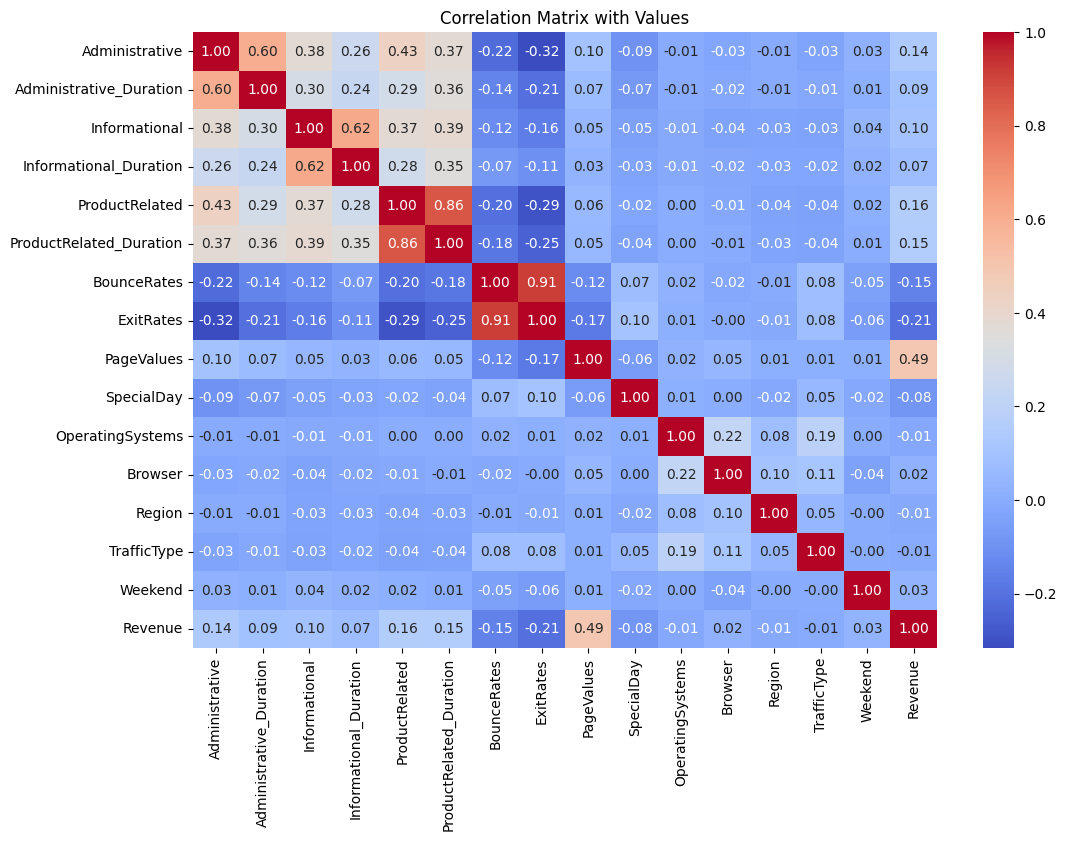

In [ ]:
# 2. Correlation Matrix (numeric)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# compute numeric correlation
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')  # 👈 values shown here
plt.title("Correlation Matrix with Values")
plt.show()



Identify Highly Correlated Features

In [ ]:
high_corr = []
moderate_corr = []

for col in corr.columns:
    for col2 in corr.columns:
        if col != col2:
            value = corr.loc[col, col2]
            if abs(value) >= 0.7:
                high_corr.append((col, col2, round(value, 3)))
            elif 0.3 <= abs(value) < 0.7:
                moderate_corr.append((col, col2, round(value, 3)))

print("Highly Correlated Features (|corr| >= 0.7):")
for x in high_corr:
    print(x)


Highly Correlated Features (|corr| >= 0.7):
('ProductRelated', 'ProductRelated_Duration', np.float64(0.861))
('ProductRelated_Duration', 'ProductRelated', np.float64(0.861))
('BounceRates', 'ExitRates', np.float64(0.913))
('ExitRates', 'BounceRates', np.float64(0.913))


In [ ]:
print(df.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')


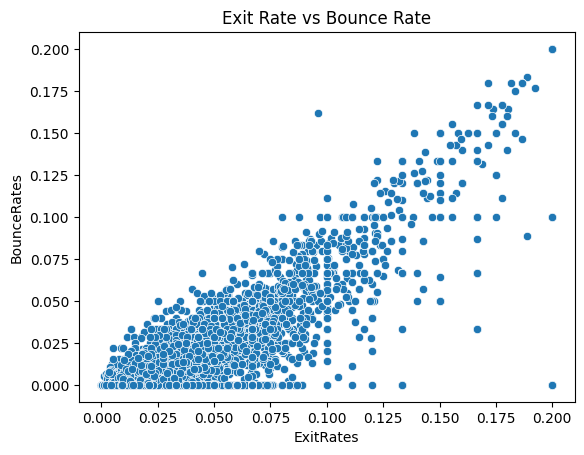

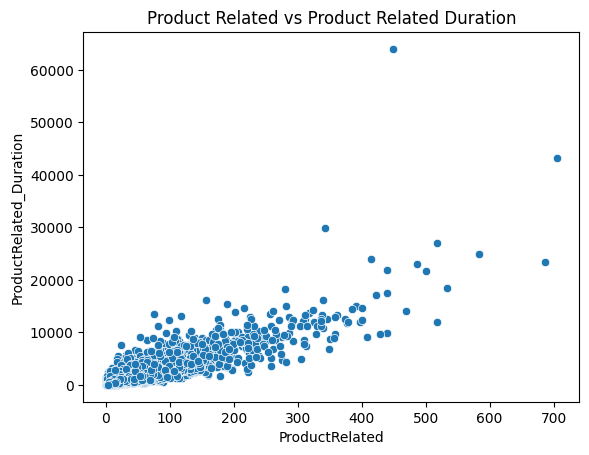

In [ ]:
# 4. Plot key correlations mentioned in the text
# -------------------------------

# ExitRate vs BounceRate
sns.scatterplot(x=df["ExitRates"], y=df["BounceRates"])
plt.title("Exit Rate vs Bounce Rate")
plt.show()

# ProductRelated vs ProductRelated_Duration
sns.scatterplot(x=df["ProductRelated"], y=df["ProductRelated_Duration"])
plt.title("Product Related vs Product Related Duration")
plt.show()

Different analysis represented in paper

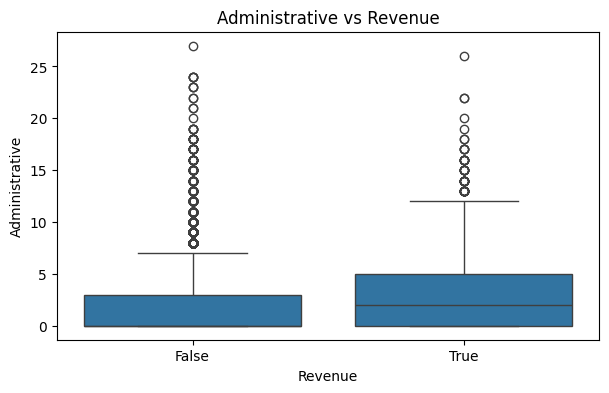

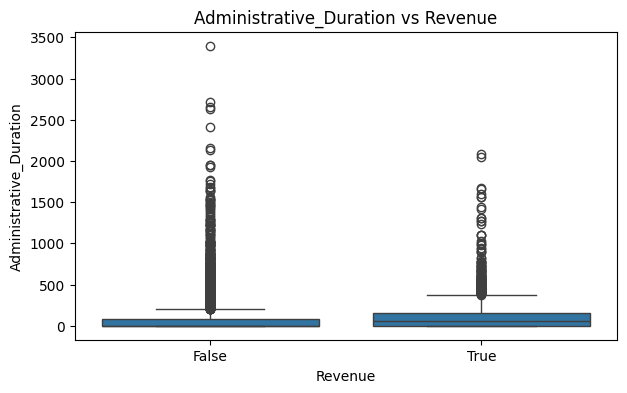

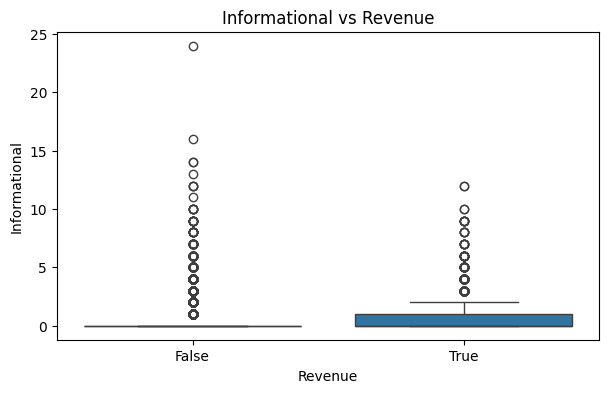

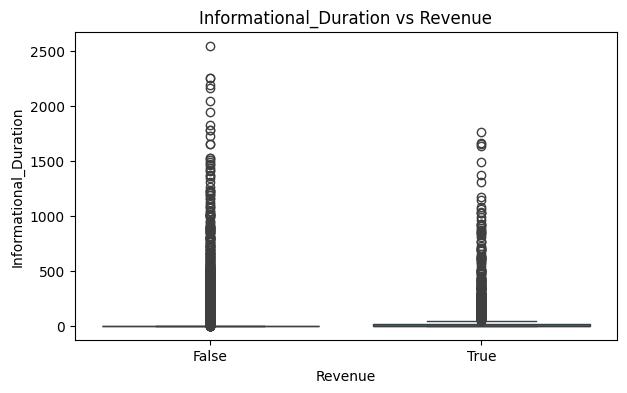

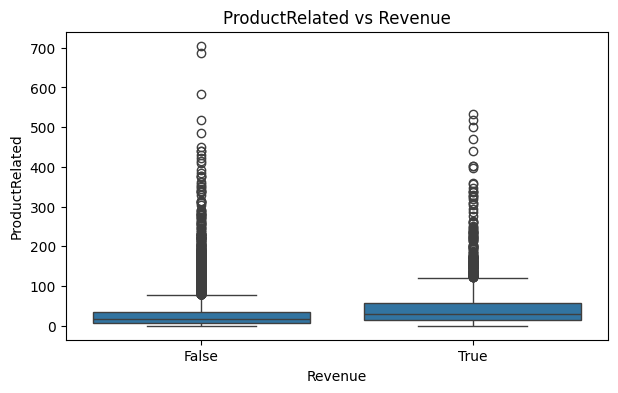

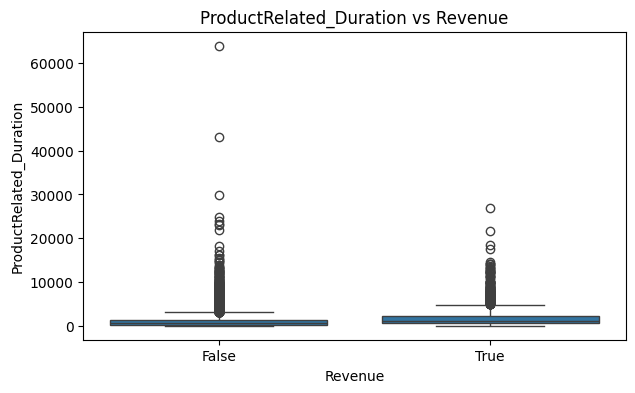

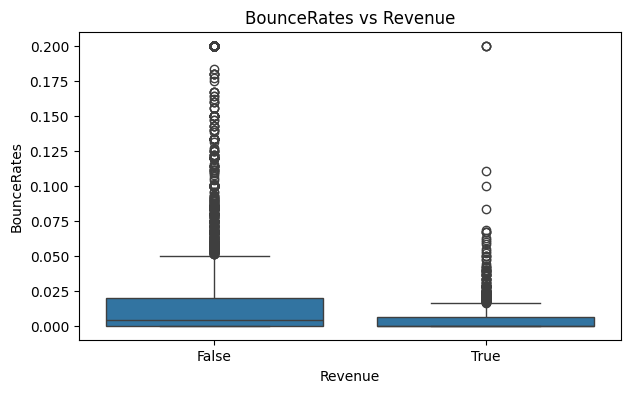

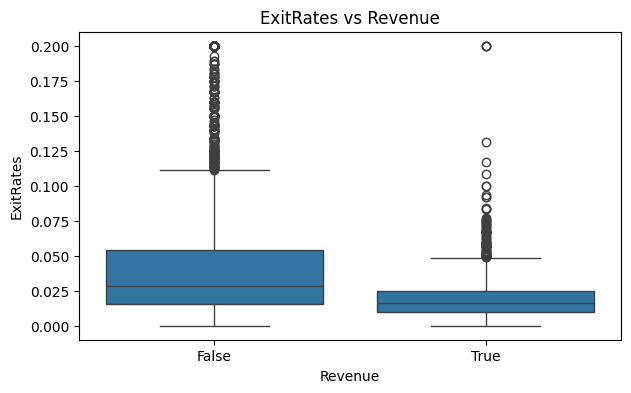

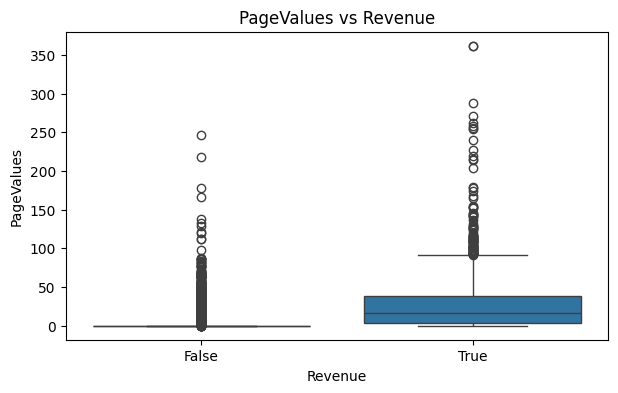

In [ ]:
web_attrs = [
    "Administrative", "Administrative_Duration",
    "Informational", "Informational_Duration",
    "ProductRelated", "ProductRelated_Duration",
    "BounceRates", "ExitRates", "PageValues"
]

for col in web_attrs:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df["Revenue"], y=df[col])
    plt.title(f"{col} vs Revenue")
    plt.show()

ANALYSIS OF PAGE-METRICS (BounceRates, ExitRates, PageValues)

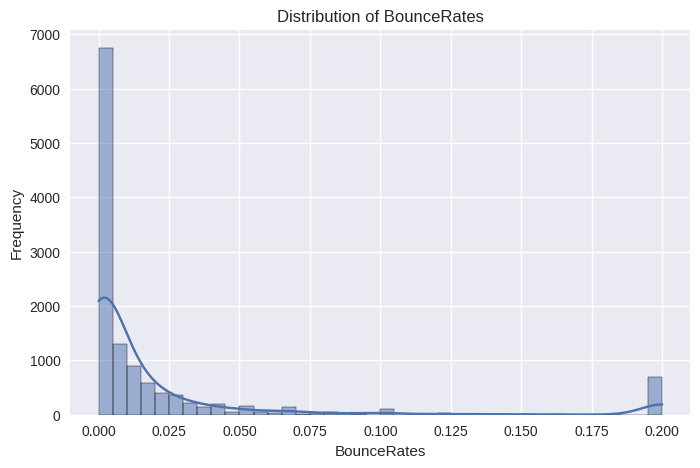

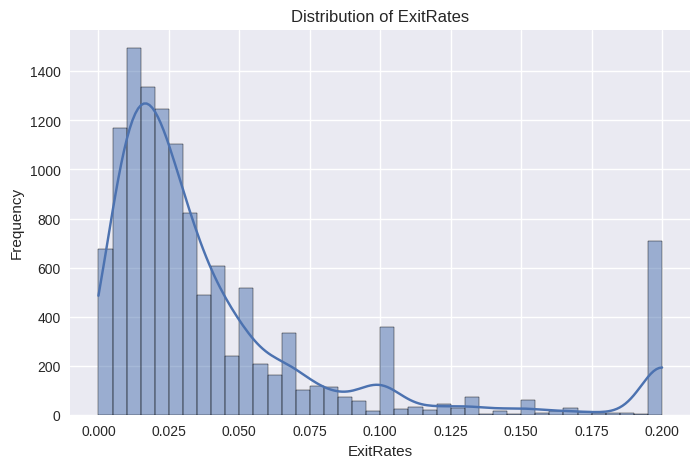

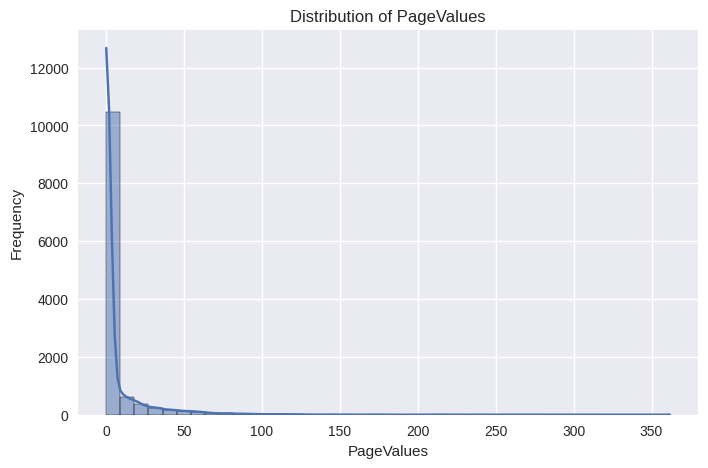

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ["BounceRates", "ExitRates", "PageValues"]

plt.style.use("seaborn-v0_8")

for col in cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True, bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


VISITOR ANALYSIS (Operating System, Browser, Region, Traffic-Type)

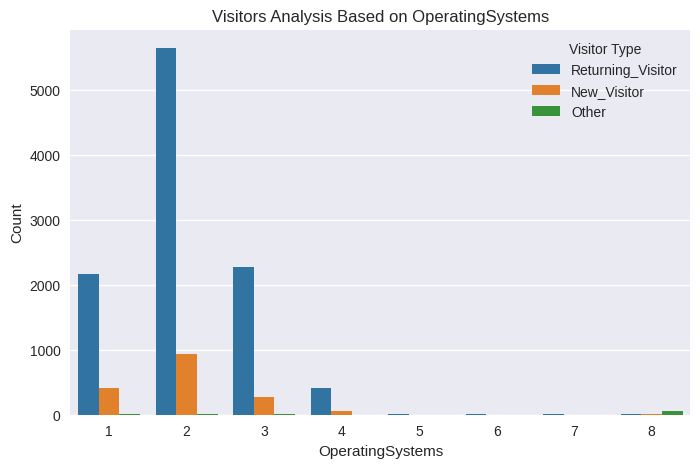

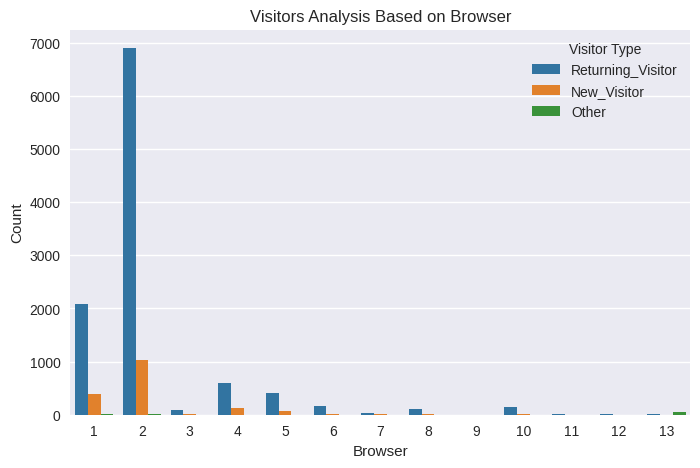

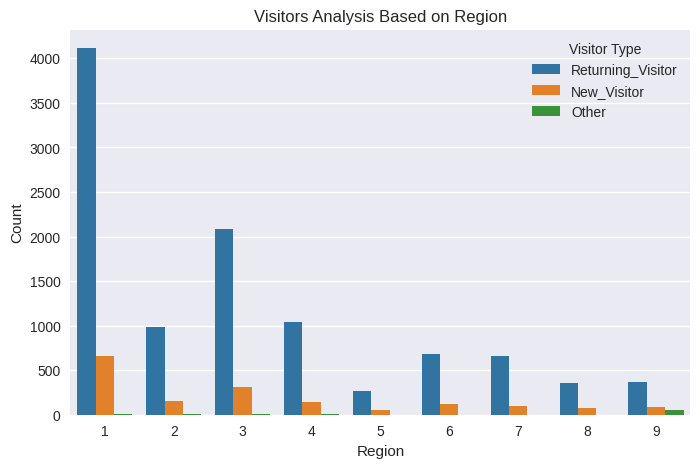

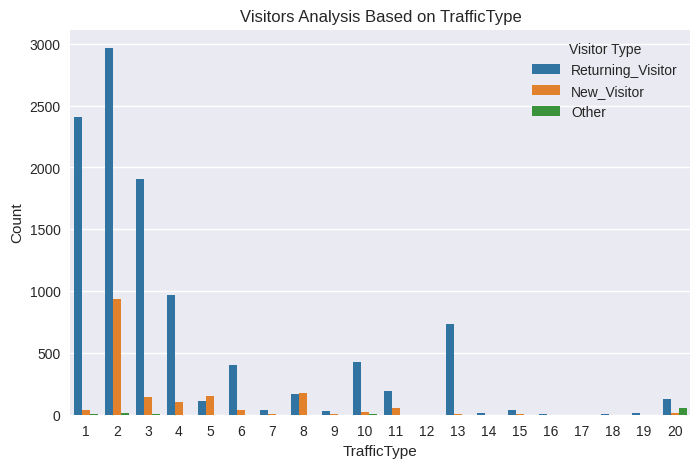

In [ ]:
visitor_cols = ["OperatingSystems", "Browser", "Region", "TrafficType"]

# Custom color palette (you can change these!)
custom_colors = {
    "Returning_Visitor": "#1f77b4",   # blue
    "New_Visitor": "#ff7f0e",         # orange
    "Other": "#2ca02c"                # green
}

for col in visitor_cols:
    plt.figure(figsize=(8,5))
    sns.countplot(
        x=df[col],
        hue=df["VisitorType"],
        palette=custom_colors
    )

    plt.title(f"Visitors Analysis Based on {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend(title="Visitor Type")
    plt.show()




REVENUE ANALYSIS BASED ON SPECIAL-DAYS

/tmp/ipython-input-4079969498.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Revenue (0 = No, 1 = Yes)")


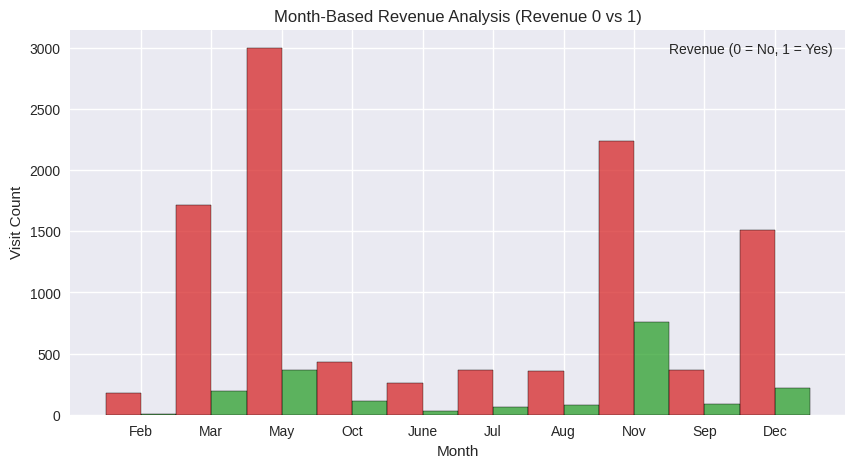

/tmp/ipython-input-4079969498.py:46: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Revenue (0 = No, 1 = Yes)")


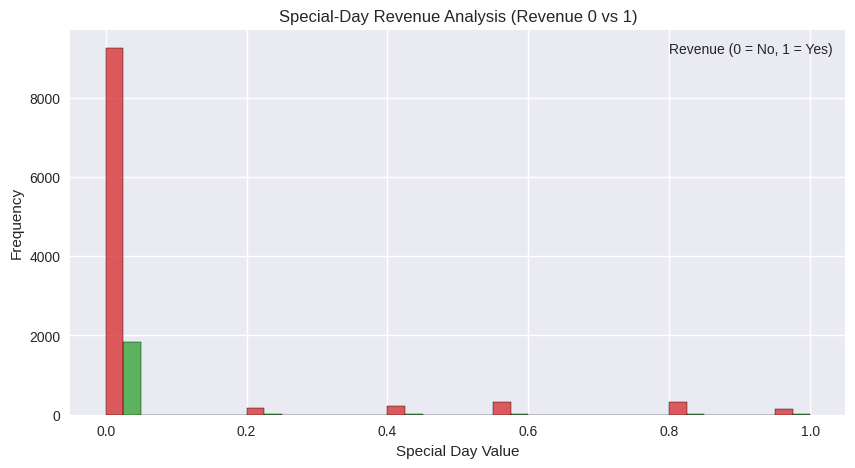

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Custom colors for revenue
rev_colors = {
    0: "#d62728",   # red for no revenue
    1: "#2ca02c"    # green for revenue
}

# ----------------------------------------------
# 1. MONTH-BASED REVENUE ANALYSIS (Separate Bars)
# ----------------------------------------------
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x="Month",
    hue="Revenue",
    multiple="dodge",      # <-- side-by-side bars
    palette=rev_colors,
    bins=12
)

plt.title("Month-Based Revenue Analysis (Revenue 0 vs 1)")
plt.xlabel("Month")
plt.ylabel("Visit Count")
plt.legend(title="Revenue (0 = No, 1 = Yes)")
plt.show()


# ----------------------------------------------
# 2. SPECIAL-DAY REVENUE ANALYSIS (Separate Bars)
# ----------------------------------------------
plt.figure(figsize=(10,5))
sns.histplot(
    data=df,
    x="SpecialDay",
    hue="Revenue",
    multiple="dodge",      # <-- side-by-side bars
    palette=rev_colors,
    bins=20
)

plt.title("Special-Day Revenue Analysis (Revenue 0 vs 1)")
plt.xlabel("Special Day Value")
plt.ylabel("Frequency")
plt.legend(title="Revenue (0 = No, 1 = Yes)")
plt.show()


/tmp/ipython-input-1752055556.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sizes = [visit_counts[0], visit_counts[1]]


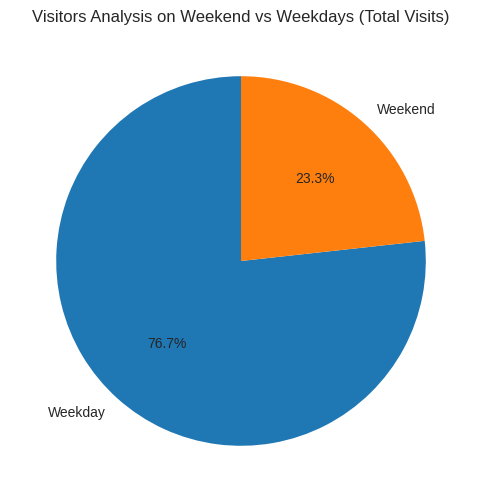

/tmp/ipython-input-1752055556.py:22: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sizes_rev = [weekend_rev[0], weekend_rev[1]]


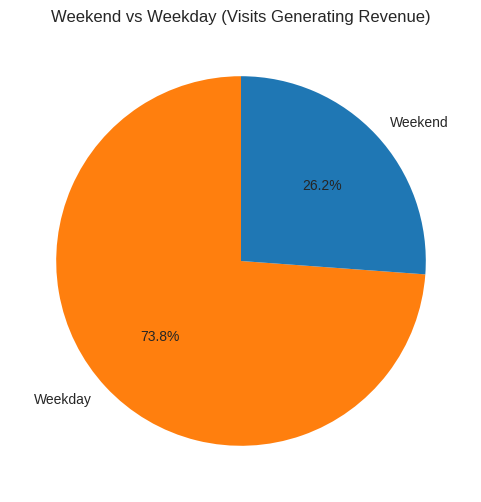

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------
# 1. Weekend vs Weekday: Total Visits
# -------------------------------
visit_counts = df["Weekend"].value_counts().sort_index()  # 0=Weekday, 1=Weekend

labels = ["Weekday", "Weekend"]
sizes = [visit_counts[0], visit_counts[1]]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90, colors=["#1f77b4", "#ff7f0e"])
plt.title("Visitors Analysis on Weekend vs Weekdays (Total Visits)")
plt.show()


# -------------------------------
# 2. Weekend vs Weekday: Visits Generating Revenue
# -------------------------------
weekend_rev = df.groupby("Weekend")["Revenue"].sum()

sizes_rev = [weekend_rev[0], weekend_rev[1]]

plt.figure(figsize=(6,6))
plt.pie(sizes_rev, labels=labels, autopct="%1.1f%%", startangle=90, colors=["#ff7f0e","#1f77b4"])
plt.title("Weekend vs Weekday (Visits Generating Revenue)")
plt.show()



Data Preprocessing

In [ ]:
df = df.copy()

# Convert boolean-like columns
for col in ["Weekend", "Revenue"]:
    if col in df.columns:
        df[col] = df[col].astype(int)

# Column lists
target_col = "Revenue"
categorical_cols = [c for c in df.select_dtypes(include=["object", "category"]).columns.tolist()
                    if c not in [target_col]]
# In this dataset Month, VisitorType are object; ensure Weekend removed
# Some numeric columns may be integer encoded categories (OperatingSystems, Browser, Region, TrafficType) - treat as numeric
numeric_cols = [c for c in df.columns if c not in categorical_cols + [target_col]]

print("Numeric cols (first 10):", numeric_cols[:10])
print("Categorical cols:", categorical_cols)

# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))

])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)


Numeric cols (first 10): ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
Categorical cols: ['Month', 'VisitorType']


Train and Test Split

In [ ]:
N_JOBS = -1
TEST_SIZE = 0.2          # 20% of data for testing
RANDOM_STATE = 42
X = df.drop(columns=[target_col])
y = df[target_col].astype(int).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Class distribution (train):", np.bincount(y_train))
print("Class distribution (test):", np.bincount(y_test))


Train shape: (9864, 17) Test shape: (2466, 17)
Class distribution (train): [8338 1526]
Class distribution (test): [2084  382]


Model and parameters

In [ ]:
models = {
    "GaussianNB": {
        "model": GaussianNB(),
        "params": {}  # GaussianNB has few params; skip heavy tuning
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__weights": ["uniform", "distance"],
            "model__leaf_size": [20, 30, 40],
            "model__p": [1, 2]
        }
    },
    "SVM": {
        "model": SVC(probability=True, random_state=RANDOM_STATE),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["rbf", "linear"],
            "model__gamma": ["scale", "auto"]
        }
    },
    "LogisticRegression": {
        "model": LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l1", "l2"]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=RANDOM_STATE),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 10, 20],
            "model__max_features": ["sqrt", "log2"],
            "model__min_samples_leaf": [1, 2, 4]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.01, 0.1],
            "model__max_depth": [3, 5]
        }
    },
    "AdaBoost": {
        "model": AdaBoostClassifier(random_state=RANDOM_STATE),
        "params": {
            "model__n_estimators": [50, 100, 200],
            "model__learning_rate": [0.01, 0.1, 1.0]
        }
    }
}

Run model with GridSearch

In [ ]:
def run_model(name, model_obj, param_grid, X_train, y_train, X_test, y_test,
              preprocessor, use_smote=False, cv=5):

    # Build pipeline
    if IMBLEARN_AVAILABLE and use_smote:
        from imblearn.pipeline import Pipeline as ImbPipeline
        pipe = ImbPipeline([
            ("preproc", preprocessor),
            ("smote", SMOTE(random_state=RANDOM_STATE)),
            ("model", model_obj)
        ])
    else:
        pipe = Pipeline([
            ("preproc", preprocessor),
            ("model", model_obj)
        ])

    # ----------------------------------------------------------
    # CASE 1: No hyperparameters → train default model
    # ----------------------------------------------------------
    if not param_grid:
        print(f"[{name}] No hyperparam grid given — fitting default model.")
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else None

        res = compute_metrics(y_test, y_pred, y_proba)
        res["model"] = pipe
        return res

    # ----------------------------------------------------------
    # CASE 2: Hyperparameter Search
    # ----------------------------------------------------------
    n_candidates = 1
    for v in param_grid.values():
        n_candidates *= max(1, len(v))

    if n_candidates <= 20:
        searcher = GridSearchCV(
            estimator=pipe,
            param_grid=param_grid,
            cv=cv,
            n_jobs=N_JOBS,
            scoring="f1_macro",
            verbose=1
        )
    else:
        searcher = RandomizedSearchCV(
            estimator=pipe,
            param_distributions=param_grid,
            n_iter=20,
            cv=cv,
            n_jobs=N_JOBS,
            scoring="f1_macro",
            random_state=RANDOM_STATE,
            verbose=1
        )

    print(f"\n[{name}] Searching hyperparams (candidates ≈ {n_candidates})...")
    searcher.fit(X_train, y_train)

    print(f"[{name}] Best params: {searcher.best_params_}")

    best = searcher.best_estimator_

    y_pred = best.predict(X_test)
    y_proba = best.predict_proba(X_test)[:, 1] if hasattr(best, "predict_proba") else None

    res = compute_metrics(y_test, y_pred, y_proba)
    res["model"] = best
    res["best_params"] = searcher.best_params_

    return res


Metrices Evaluation

In [ ]:
def compute_metrics(y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else None
    cm = confusion_matrix(y_true, y_pred)
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc, "confusion_matrix": cm}

Test Models using 5 folds

In [ ]:
results = {}
use_smote = False  # set True to try SMOTE balancing (paper did mention imbalance; they didn't use SMOTE explicitly)
cv_folds = 5

for name, info in models.items():
    try:
        res = run_model(name, info["model"], info["params"], X_train, y_train, X_test, y_test, preprocessor, use_smote=use_smote, cv=cv_folds)
        results[name] = res
    except Exception as e:
        print(f"ERROR running {name}: {e}")



[GaussianNB] No hyperparam grid given — fitting default model.

[KNN] Searching hyperparams (candidates ≈ 48)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[KNN] Best params: {'model__weights': 'distance', 'model__p': 2, 'model__n_neighbors': 3, 'model__leaf_size': 30}

[SVM] Searching hyperparams (candidates ≈ 12)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
[SVM] Best params: {'model__C': 10, 'model__gamma': 'auto', 'model__kernel': 'rbf'}

[LogisticRegression] Searching hyperparams (candidates ≈ 8)...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
[LogisticRegression] Best params: {'model__C': 10, 'model__penalty': 'l1'}

[RandomForest] Searching hyperparams (candidates ≈ 36)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[RandomForest] Best params: {'model__n_estimators': 200, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': 20}

[GradientBoosting] Searching hyperparams (candidates 

Save results

In [ ]:
from pathlib import Path
import pandas as pd

# ---------------------------
# Define output directory
# ---------------------------
OUTPUT_DIR = Path("results")         # folder name
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)  # create folder if it doesn't exist

# ---------------------------
# Summarize results
# ---------------------------
rows = []
for name, r in results.items():
    cm = r.get("confusion_matrix")
    tn, fp, fn, tp = cm.ravel() if cm is not None and cm.size == 4 else (None,)*4
    rows.append({
        "model": name,
        "accuracy": r.get("accuracy"),
        "precision": r.get("precision"),
        "recall": r.get("recall"),
        "f1": r.get("f1"),
        "roc_auc": r.get("roc_auc"),
        "tn": tn, "fp": fp, "fn": fn, "tp": tp,
        "best_params": r.get("best_params", "")
    })

res_df = pd.DataFrame(rows).sort_values(by="accuracy", ascending=False)

# ---------------------------
# Save to CSV
# ---------------------------
res_df.to_csv(OUTPUT_DIR / "results_by_model.csv", index=False)

print("\nResults summary:\n", res_df)



Results summary:
                 model  accuracy  precision    recall        f1   roc_auc  \
5    GradientBoosting  0.901460   0.723473  0.589005  0.649351  0.928588   
4        RandomForest  0.900649   0.750916  0.536649  0.625954  0.923487   
2                 SVM  0.887672   0.689531  0.500000  0.579666  0.858756   
3  LogisticRegression  0.881184   0.743169  0.356021  0.481416  0.887185   
6            AdaBoost  0.879562   0.603912  0.646597  0.624526  0.897943   
1                 KNN  0.867397   0.606178  0.410995  0.489860  0.752623   
0          GaussianNB  0.673560   0.294060  0.790576  0.428673  0.793901   

     tn   fp   fn   tp                                        best_params  
5  1998   86  157  225  {'model__learning_rate': 0.1, 'model__max_dept...  
4  2016   68  177  205  {'model__n_estimators': 200, 'model__min_sampl...  
2  1998   86  191  191  {'model__C': 10, 'model__gamma': 'auto', 'mode...  
3  2037   47  246  136           {'model__C': 10, 'model__penalty': 

ROC Curve of all models

ROC curves saved to results/roc_curves.png


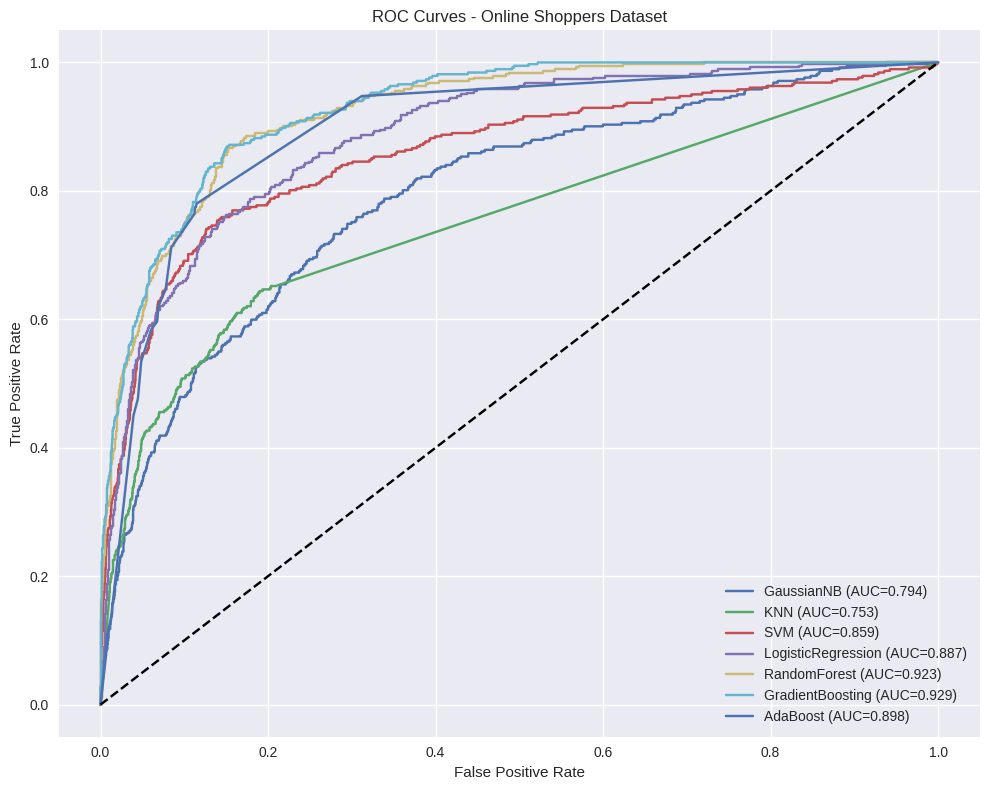

In [ ]:
# Plot ROC curves for all models that provide probabilities
# ---------------------------
plt.figure(figsize=(10, 8))
for name, r in results.items():
    model = r["model"]
    # get pipeline to transform test data -> then predict_proba
    try:
        if hasattr(model, "predict_proba"):
            # compute predicted probs / ROC
            # For pipelines: need to call predict_proba on pipeline
            y_proba = model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            auc_val = roc_auc_score(y_test, y_proba)
            plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})")
    except Exception as e:
        print(f"Could not compute ROC for {name}: {e}")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Online Shoppers Dataset")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_curves.png")
print(f"ROC curves saved to {OUTPUT_DIR/'roc_curves.png'}")


In [ ]:
# ---------------------------
# Save best model (highest accuracy)
# ---------------------------
best_row = res_df.iloc[0]
best_name = best_row["model"]
best_model = results[best_name]["model"]
import joblib
joblib.dump(best_model, OUTPUT_DIR / f"best_model_{best_name}.pkl")
print(f"Saved best model ({best_name}) to {OUTPUT_DIR/f'best_model_{best_name}.pkl'}")


Saved best model (GradientBoosting) to results/best_model_GradientBoosting.pkl


In [ ]:
# Print detailed best model metrics
# ---------------------------
print("\nDetailed best model metrics:")
print(res_df.iloc[0].to_dict())

print("\nDone. Summary CSV and plots saved in:", OUTPUT_DIR.resolve())


Detailed best model metrics:
{'model': 'GradientBoosting', 'accuracy': 0.9014598540145985, 'precision': 0.7234726688102894, 'recall': 0.5890052356020943, 'f1': 0.6493506493506493, 'roc_auc': 0.9285876686999427, 'tn': 1998, 'fp': 86, 'fn': 157, 'tp': 225, 'best_params': {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}}

Done. Summary CSV and plots saved in: /content/results
